### Tidyverser and queries

In [4]:
require(tidyverse)
require(duckdb)

In [3]:
conn <- dbConnect(duckdb())

In [6]:
players <- read_csv("data/male_players.csv")

Rows: 180021 Columns: 109
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (43): player_url, short_name, long_name, player_positions, club_name, l...
dbl  (63): player_id, fifa_version, fifa_update, overall, potential, value_e...
date  (3): update_as_of, dob, club_joined_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
dbGetQuery(conn, "SELECT * FROM 'data/male_players.csv'") -> players

In [6]:
duckdb_register(conn, 'players', players )

In [13]:
dbGetQuery(conn, "
SELECT * FROM players
") |> tibble() -> clean_players

In [22]:
#Operators 
# mathematical + - / * ^ %
#comparison > < >= <= == != %in%
'pepper' %in% c('mango', 'pawpaw', 'guava')
#logical operators & |
#special operators |> :
3:15

 [1]  3  4  5  6  7  8  9 10 11 12 13 14 15

In [14]:
clean_players |> 
  select(short_name, overall, potential, nationality_name, league_name) |> 
  filter(overall > 90 |  nationality_name == 'France')

# A tibble: 9,706 × 5
   short_name   overall potential nationality_name league_name   
   <chr>          <dbl>     <dbl> <chr>            <chr>         
 1 K. Mbappé         91        94 France           Ligue 1       
 2 E. Haaland        91        94 Norway           Premier League
 3 K. De Bruyne      91        91 Belgium          Premier League
 4 K. Benzema        90        90 France           Pro League    
 5 A. Griezmann      88        88 France           La Liga       
 6 M. Maignan        87        89 France           Serie A       
 7 C. Nkunku         86        88 France           Premier League
 8 O. Dembélé        86        87 France           Ligue 1       
 9 N. Kanté          86        86 France           Pro League    
10 T. Hernández      85        90 France           Serie A       
# ℹ 9,696 more rows
# ℹ Use `print(n = ...)` to see more rows

# Probability theory

### Rule 1
$$ 0 \le P(X) \le 1 $$

### Rule 2

$$ \sum{P(X_i)} = 1 $$

### Rule 3: compliment rule

$$ P(X) = 1 - P(X_c)$$

# Joint, marginal and conditional probabilities

|.| A | C |
|-|---|---|
|B| 22| 31|
|G| 13| 34|

# Marginal Probabilities

- P(B) = 22 + 31 / 100 = 0.53
- P(G) = 13 + 34 / 100 = 0.47
- P(A) = 22 + 13 / 100 = 0.35
- P(C) = 31 + 34 / 100 = 0.65

# Joint Probabilities
- $P(A\cap{B})$ = 22/100 = 0.22
- $P(A\cap{G})$ = 13/100 = 0.13
- $P(C\cap{B})$ = 31/100 = 0.31
- $P(C\cap{G})$ = 34/100 = 0.34

# Conditional Probabilities
- P(B|A) = 22/(22+13) = 0.62
- P(A|B) = 22/(22+31) = 0.42
- P(G|C) = 34/(31+34) = 0.52
- P(C|G) = 34/(13+34) = 0.72
- P(B|C) = 31/(31+34) = 0.48
- P(C|B) = 31/(22+31) = 0.58
- P(G|A) = 13/(22+13) = 0.38
- P(A|G) = 13/(13+34) = 0.28


### Aggregation

In [15]:
dbGetQuery(conn, "
SELECT 
  nationality_name, 
  AVG(Age) AS average_age, 
  MIN(Age) AS minimum_age,
  MAX(Age) AS maximum_age
FROM players 
GROUP BY nationality_name
") |> tibble()

# A tibble: 188 × 4
   nationality_name average_age minimum_age maximum_age
   <chr>                  <dbl>       <dbl>       <dbl>
 1 Uruguay                 26.3          17          41
 2 Switzerland             24.5          17          38
 3 Colombia                25.5          16          44
 4 Israel                  25.8          19          36
 5 Iceland                 25.7          16          38
 6 Honduras                26.8          18          38
 7 Madagascar              27.7          17          37
 8 Congo                   25.0          17          34
 9 Panama                  26.9          19          36
10 Uzbekistan              27.1          18          33
# ℹ 178 more rows
# ℹ Use `print(n = ...)` to see more rows

In [16]:
dbGetQuery(conn, "
SELECT 
  nationality_name, 
  AVG(Wage_eur) AS average_salary, 
  MIN(Wage_eur) AS minimum_salary,
  MAX(Wage_eur) AS maximum_salary
FROM players 
GROUP BY nationality_name
") |> tibble()

# A tibble: 188 × 4
   nationality_name average_salary minimum_salary maximum_salary
   <chr>                     <dbl>          <dbl>          <dbl>
 1 France                   14239.            500         450000
 2 Portugal                 16061.            500         575000
 3 Egypt                    30184.            500         270000
 4 Senegal                  14938.            500         270000
 5 Turkey                   12246.            500         225000
 6 Canada                    5183.            500          80000
 7 Côte d'Ivoire            16657.            500         190000
 8 Sweden                    5876.            500         300000
 9 Paraguay                  7101.            500         130000
10 Mozambique               16353.            600          60000
# ℹ 178 more rows
# ℹ Use `print(n = ...)` to see more rows

In [17]:
clean_players |> 
  #filter(nationality_name %in% c('Nigeria', 'England', 'Brazil', 'South Africa','Ghana')) |> 
  group_by(nationality_name) |> 
  summarise(
    Players = n(), 
    Average_Salary = median(wage_eur, na.rm=T), 
    Maximum_Salary = max(wage_eur, na.rm=T) 
  ) |> 
  arrange(Average_Salary |> desc()) -> wide_data

In [18]:
wide_data |> 
  pivot_longer(c(Players, Average_Salary, Maximum_Salary), names_to="Summary_description", values_to="Summary_values") -> long_data

In [19]:
long_data

# A tibble: 564 × 3
   nationality_name    Summary_description Summary_values
   <chr>               <chr>                        <dbl>
 1 Kuwait              Players                          7
 2 Kuwait              Average_Salary               20000
 3 Kuwait              Maximum_Salary               50000
 4 Oman                Players                          6
 5 Oman                Average_Salary               15000
 6 Oman                Maximum_Salary               35000
 7 Chad                Players                         12
 8 Chad                Average_Salary               12500
 9 Chad                Maximum_Salary               30000
10 São Tomé e Príncipe Players                          7
# ℹ 554 more rows
# ℹ Use `print(n = ...)` to see more rows

In [57]:
?pivot_longer()

In [62]:
long_data |> 
  pivot_wider(names_from=Summary_description, values_from=Summary_values)

# A tibble: 188 × 4
   nationality_name    Players Average_Salary Maximum_Salary
   <chr>                 <dbl>          <dbl>          <dbl>
 1 Kuwait                    7          20000          50000
 2 Oman                      6          15000          35000
 3 Chad                     12          12500          30000
 4 São Tomé e Príncipe       7          12000          30000
 5 Egypt                   256          11000         270000
 6 Algeria                 528          10000         220000
 7 Brazil                 7899          10000         450000
 8 Mozambique               47          10000          60000
 9 Belarus                  71           9000          40000
10 Uzbekistan               45           9000          80000
# ℹ 178 more rows
# ℹ Use `print(n = ...)` to see more rows

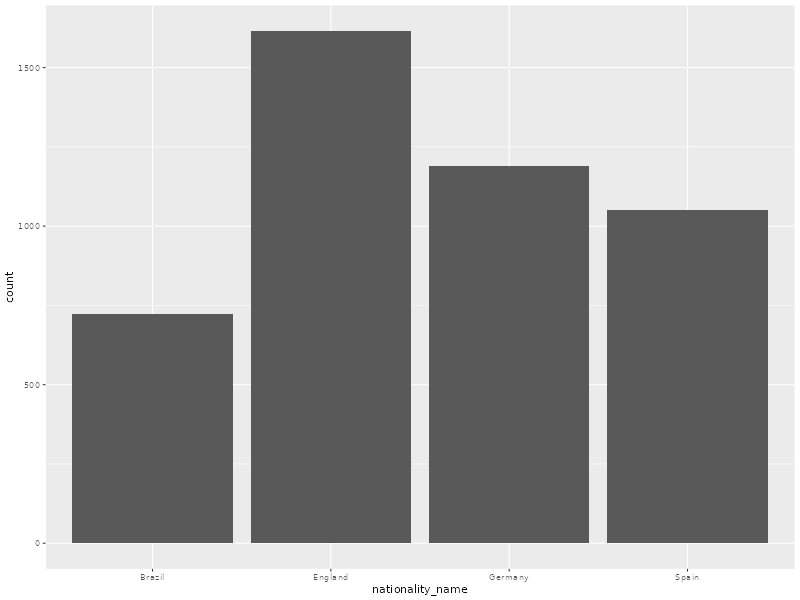

In [72]:
# GGPlot

clean_players |> 
  filter(fifa_version == '24') |> 
  filter(nationality_name %in% c('England', 'Spain', 'Brazil', 'Germany')) |> 
  ggplot() + aes(x=nationality_name) + geom_bar()

Warning message:
Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


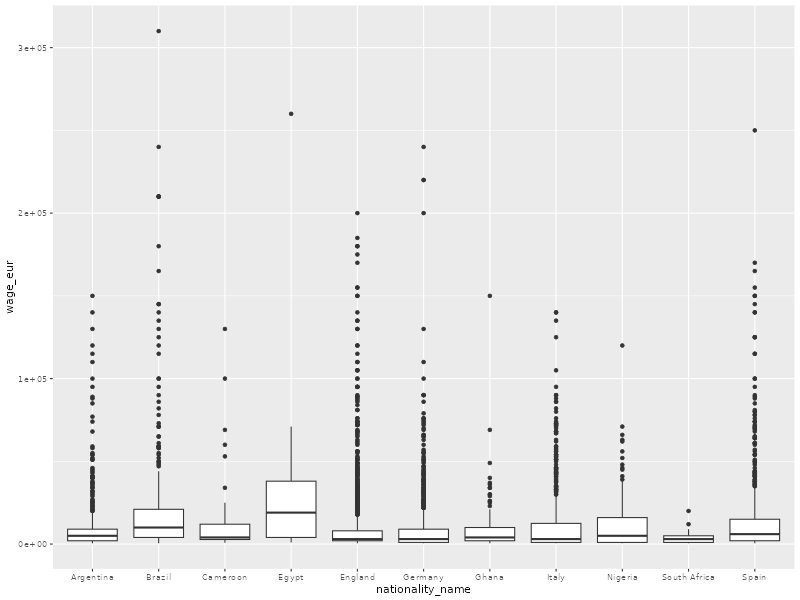

In [76]:
clean_players |> 
  filter(fifa_version == '24') |>
  filter(nationality_name %in% c('Brazil', 'Argentina', 'England', 'Germany', 'Spain', 'Italy', 'Nigeria', 'Ghana', 'Cameroon', 'South Africa', 'Egypt')) |> 
  ggplot() + aes(x=nationality_name, y=wage_eur) + geom_boxplot()